<a href="https://colab.research.google.com/github/higinosk/analise-profissionais-de-dados/blob/dev/Analise_Profissionais_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise do perfil de profissionais de dados no Brasil

**Autora:** Kamilly Higino  
**Projeto de portfólio:** Análise de dados com Python, Pandas, SQL e estatística

Este projeto investiga características demográficas, educacionais e salariais de profissionais da área de dados. O foco está na qualidade da preparação dos dados, na clareza das visualizações e na interpretação responsável dos resultados.

## 1. Contexto e perguntas de negócio

A análise procura responder:

1. Qual é o perfil das pessoas participantes da pesquisa?
2. Como os salários estão distribuídos?
3. Como a remuneração varia entre grupos presentes na base?
4. Existe associação entre idade e salário?
5. Quais limitações precisam ser consideradas antes de generalizar os resultados?

> As relações encontradas são associações estatísticas e não demonstram causalidade.

## 2. Tecnologias utilizadas

- Python
- Pandas e NumPy
- Matplotlib e Seaborn
- SciPy
- SQLite e SQL

O notebook pode ser executado no Google Colab ou localmente. Ele tenta carregar a planilha pública `analise_dados_limpo.xlsx`; como alternativa, aceita o mesmo arquivo na pasta `data/` ou por upload no Colab.

## 3. Metodologia

O trabalho foi organizado em cinco etapas:

1. Carregamento e entendimento da base;
2. Avaliação e tratamento da qualidade dos dados;
3. Análise exploratória e visualização;
4. Análises estatísticas e consulta SQL;
5. Síntese dos resultados, limitações e conclusão.

In [29]:
from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)

    class Markdown(str):
        pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14

In [30]:
# Fonte compartilhada pela Programaria
URL_DADOS = "https://docs.google.com/spreadsheets/d/1OmmW_3K1xB9vaGIzjvtHJxJXj_RlFWAg/export?format=xlsx"

# Procura primeiro uma cópia local, deixando o projeto reproduzível offline.
candidatos = [
    Path("data/analise_dados_limpo.xlsx"),
    Path("../data/analise_dados_limpo.xlsx"),
    Path("analise_dados_limpo.xlsx"),
    Path("/content/analise_dados_limpo.xlsx"),
]
arquivo = next((caminho for caminho in candidatos if caminho.exists()), None)

if arquivo is not None:
    dados_brutos = pd.read_excel(arquivo)
    fonte_dados = str(arquivo)
else:
    try:
        dados_brutos = pd.read_excel(URL_DADOS)
        fonte_dados = URL_DADOS
    except Exception as erro_download:
        try:
            from google.colab import files
            print("Selecione o arquivo analise_dados_limpo.xlsx")
            enviados = files.upload()
            arquivo = Path(next(iter(enviados)))
            dados_brutos = pd.read_excel(arquivo)
            fonte_dados = str(arquivo)
        except (ImportError, StopIteration):
            raise FileNotFoundError(
                "Base não encontrada. Coloque analise_dados_limpo.xlsx na pasta data/."
            ) from erro_download

print(f"Base carregada de: {fonte_dados}")

Base carregada de: https://docs.google.com/spreadsheets/d/1OmmW_3K1xB9vaGIzjvtHJxJXj_RlFWAg/export?format=xlsx


In [31]:
def moeda(valor):
    '''Formata valores monetários no padrão brasileiro.'''
    if pd.isna(valor):
        return "Não disponível"
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def converter_numero(serie):
    '''Converte colunas numéricas, inclusive quando há vírgula decimal.'''
    if pd.api.types.is_numeric_dtype(serie):
        return pd.to_numeric(serie, errors="coerce")
    texto = serie.astype("string").str.strip()
    texto = texto.str.replace(r"R\$\s*", "", regex=True)
    texto = texto.str.replace(r"\.(?=\d{3}(?:\D|$))", "", regex=True)
    texto = texto.str.replace(",", ".", regex=False)
    return pd.to_numeric(texto, errors="coerce")

## 4. Conhecendo os dados

Primeiro, verificamos o tamanho, as primeiras linhas e a estrutura da base. Essa etapa evita que decisões de limpeza sejam tomadas sem entender os dados disponíveis.

In [32]:
linhas_iniciais, colunas_iniciais = dados_brutos.shape
print(f"A base possui {linhas_iniciais:,} registros e {colunas_iniciais} colunas.")
dados_brutos.head()

A base possui 4,197 registros e 46 colunas.


,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,UF ONDE MORA,REGIAO ONDE MORA,MUDOU DE ESTADO?,REGIAO DE ORIGEM,NIVEL DE ENSINO,ÁREA DE FORMAÇÃO,QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO,NOVO_NIVEL,NIVEL_Júnior,NIVEL_Pleno,NIVEL_Sênior,GEARACAO,Quanto tempo de experiência na área de dados você tem?,Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?,Você está satisfeito na sua empresa atual?,Qual o principal motivo da sua insatisfação com a empresa atual?,Você participou de entrevistas de emprego nos últimos 6 meses?,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),DF,Centro-oeste,0.0,Sudeste,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Servidor Público,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0,Júnior,True,False,False,Millenial,de 1 a 2 anos,de 7 a 10 anos,1.0,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),PA,Norte,1.0,NaN,Graduação/Bacharelado,Outras Engenharias,Empregado (CLT),Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0,Pessoa Gestora,False,False,False,Millenial,de 3 a 4 anos,Menos de 1 ano,0.0,Falta de oportunidade de crescimento no empreg...,"Sim, fiz entrevistas mas não fui aprovado",Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),DF,Centro-oeste,0.0,Sul,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0,Pleno,False,True,False,Geração X,de 3 a 4 anos,Mais de 10 anos,0.0,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gera

In [33]:
dados_brutos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4197 entries, 0 to 4196
Data columns (total 46 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   ID                                                                                                                         4197 non-null   object 
 1   IDADE                                                                                                                      4197 non-null   int64  
 2   FAIXA IDADE                                                                                                                4197 non-null   object 
 3   GENERO                                                                                                                     4197 

In [34]:
# Padronização dos nomes sem alterar o significado das variáveis.
dados = dados_brutos.copy()
dados.columns = dados.columns.astype(str).str.strip()
dados = dados.drop(columns=[c for c in dados.columns if c.startswith("Unnamed:")], errors="ignore")

colunas_principais = [
    "ID", "IDADE", "FAIXA IDADE", "GENERO", "COR/RACA/ETNIA",
    "NIVEL DE ENSINO", "UF ONDE MORA", "NIVEL", "GESTOR?",
    "FAIXA SALARIAL", "SALARIO"
]

pd.DataFrame({
    "coluna": colunas_principais,
    "disponível": [coluna in dados.columns for coluna in colunas_principais]
})

,coluna,disponível
0,ID,True
1,IDADE,True
2,FAIXA IDADE,True
3,GENERO,True
4,COR/RACA/ETNIA,True
5,NIVEL DE ENSINO,True
6,UF ONDE MORA,True
7,NIVEL,False
8,GESTOR?,True
9,FAIXA SALARIAL,True


## 5. Qualidade e preparação dos dados

As decisões adotadas são conservadoras:

- valores ausentes de gênero recebem a categoria `Prefiro não informar`;
- idades impossíveis ficam ausentes, sem excluir toda a resposta;
- salários ausentes permanecem ausentes nas análises salariais;
- salários elevados são sinalizados como possíveis outliers, mas não são substituídos automaticamente;
- o número de registros é auditado antes e depois da preparação.

In [35]:
qualidade = (
    dados.isna().mean().mul(100)
    .sort_values(ascending=False)
    .rename("percentual_ausente")
    .to_frame()
)
qualidade.head(15).round(1)

,percentual_ausente
CARGO COMO GESTOR,83.3
REGIAO DE ORIGEM,82.1
ASPECTOS_PREJUDICADOS,80.3
Qual o principal motivo da sua insatisfação com a empresa atual?,77.5
EXPERIENCIA_PROFISSIONAL_PREJUDICADA,48.6
Quais das linguagens listadas abaixo você utiliza no trabalho?,29.9
CARGO ATUAL,29.9
SETOR,13.2
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,13.2
NUMERO DE FUNCIONARIOS,13.2


In [36]:
if "ID" in dados.columns:
    duplicados = int(dados["ID"].duplicated().sum())
    print(f"IDs duplicados: {duplicados}")
else:
    duplicados = int(dados.duplicated().sum())
    print(f"Linhas completamente duplicadas: {duplicados}")

IDs duplicados: 1


In [37]:
# Conversão das variáveis utilizadas nas análises.
for coluna in ["IDADE", "SALARIO"]:
    if coluna not in dados.columns:
        raise KeyError(f"A coluna obrigatória {coluna!r} não foi encontrada.")
    dados[coluna] = converter_numero(dados[coluna])

if "GENERO" not in dados.columns:
    raise KeyError("A coluna obrigatória 'GENERO' não foi encontrada.")

dados["GENERO"] = dados["GENERO"].fillna("Prefiro não informar").astype(str).str.strip()
dados["IDADE_VALIDA"] = dados["IDADE"].where(dados["IDADE"].between(16, 100))

if "NOVO_NIVEL" in dados.columns:
    dados["NIVEL_ANALISE"] = dados["NOVO_NIVEL"]
elif "NIVEL" in dados.columns:
    dados["NIVEL_ANALISE"] = dados["NIVEL"]
    if "GESTOR?" in dados.columns:
        gestor = converter_numero(dados["GESTOR?"])
        dados.loc[gestor.eq(1), "NIVEL_ANALISE"] = "Pessoa Gestora"
else:
    dados["NIVEL_ANALISE"] = pd.NA

In [38]:
auditoria = pd.Series({
    "registros_iniciais": linhas_iniciais,
    "registros_após_preparação": len(dados),
    "idades_inválidas_ou_ausentes": int(dados["IDADE_VALIDA"].isna().sum()),
    "salários_ausentes": int(dados["SALARIO"].isna().sum()),
    "gêneros_não_informados": int(dados["GENERO"].eq("Prefiro não informar").sum()),
})
auditoria.to_frame("quantidade")

,quantidade
registros_iniciais,4197
registros_após_preparação,4197
idades_inválidas_ou_ausentes,0
salários_ausentes,0
gêneros_não_informados,19


## 6. Análise descritiva dos salários

Média e mediana são apresentadas juntas porque a distribuição salarial pode ser assimétrica. A mediana costuma representar melhor o valor central quando existem salários muito altos.

In [39]:
salarios = dados["SALARIO"].dropna()

resumo_salario = pd.Series({
    "quantidade": salarios.count(),
    "média": salarios.mean(),
    "mediana": salarios.median(),
    "desvio padrão": salarios.std(ddof=1),
    "mínimo": salarios.min(),
    "máximo": salarios.max(),
})
resumo_salario.to_frame("valor").round(2)

,valor
quantidade,4197.00
média,9917.68
mediana,7625.50
desvio padrão,8323.83
mínimo,35.00
máximo,63813.00


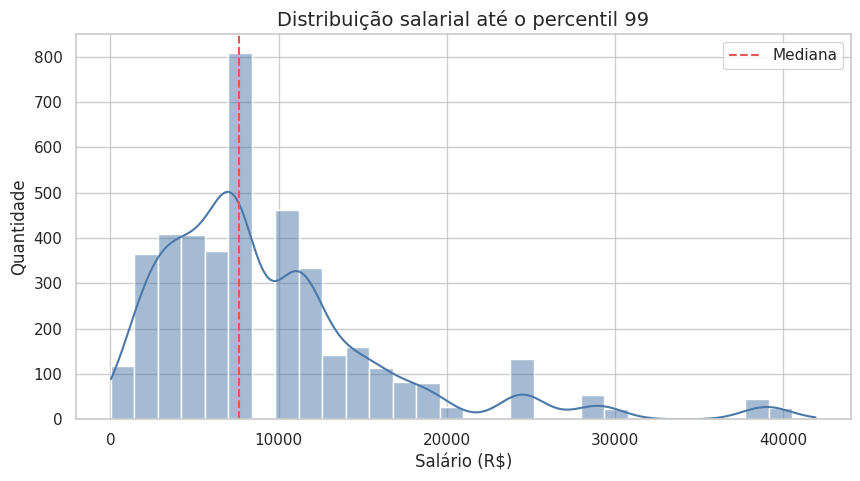

In [40]:
limite_visual = salarios.quantile(0.99)

fig, ax = plt.subplots()
sns.histplot(salarios[salarios <= limite_visual], bins=30, kde=True, ax=ax, color="#4C78A8")
ax.axvline(salarios.median(), color="#E45756", linestyle="--", label="Mediana")
ax.set(title="Distribuição salarial até o percentil 99", xlabel="Salário (R$)", ylabel="Quantidade")
ax.legend()
plt.show()

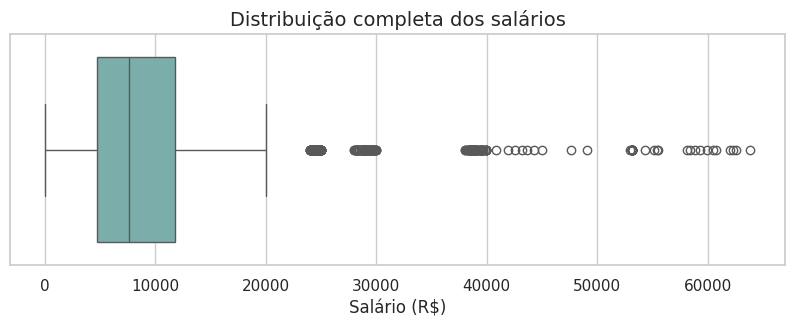

In [41]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=salarios, ax=ax, color="#72B7B2")
ax.set(title="Distribuição completa dos salários", xlabel="Salário (R$)")
plt.show()

In [42]:
q1, q3 = salarios.quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
possiveis_outliers = salarios[(salarios < limite_inferior) | (salarios > limite_superior)]

print(f"Limite inferior pelo IQR: {moeda(limite_inferior)}")
print(f"Limite superior pelo IQR: {moeda(limite_superior)}")
print(f"Possíveis outliers: {len(possiveis_outliers)} ({len(possiveis_outliers) / len(salarios):.1%})")
print("Os valores foram mantidos, pois um outlier estatístico não é necessariamente um erro.")

Limite inferior pelo IQR: R$ -5.845,50
Limite superior pelo IQR: R$ 22.382,50
Possíveis outliers: 322 (7.7%)
Os valores foram mantidos, pois um outlier estatístico não é necessariamente um erro.


## 7. Perfil das pessoas participantes

Nesta etapa são observadas a composição por gênero, a distribuição de idade, a escolaridade e a localização. Categorias com poucas respostas devem ser interpretadas com cautela.

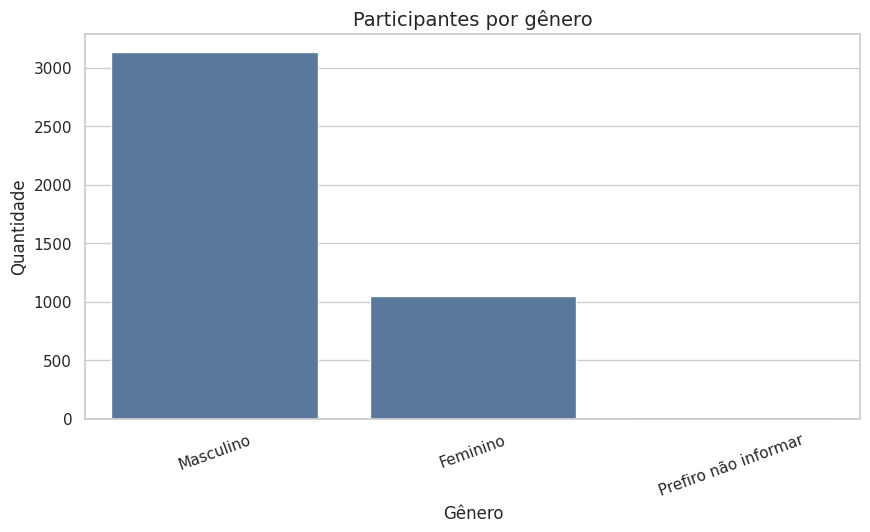

In [43]:
genero_contagem = dados["GENERO"].value_counts().rename_axis("gênero").reset_index(name="quantidade")

fig, ax = plt.subplots()
sns.barplot(data=genero_contagem, x="gênero", y="quantidade", ax=ax, color="#4C78A8")
ax.set(title="Participantes por gênero", xlabel="Gênero", ylabel="Quantidade")
ax.tick_params(axis="x", rotation=20)
plt.show()

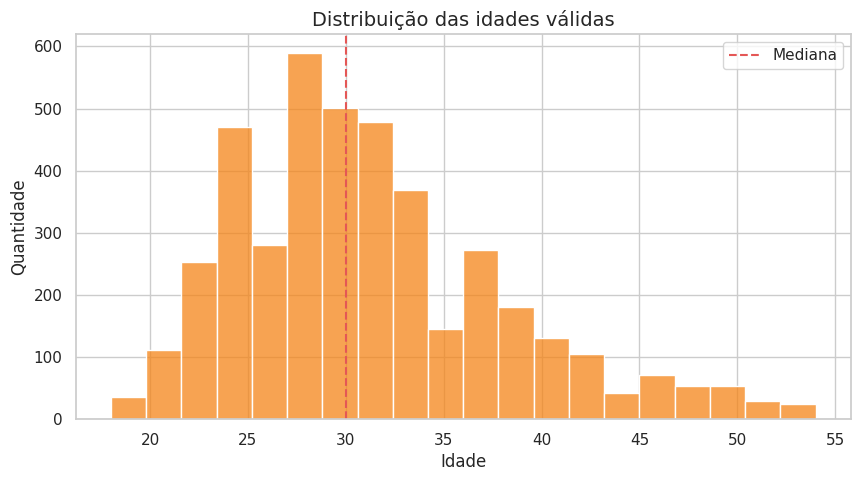

In [44]:
fig, ax = plt.subplots()
sns.histplot(dados["IDADE_VALIDA"].dropna(), bins=20, ax=ax, color="#F58518")
ax.axvline(dados["IDADE_VALIDA"].median(), color="#E45756", linestyle="--", label="Mediana")
ax.set(title="Distribuição das idades válidas", xlabel="Idade", ylabel="Quantidade")
ax.legend()
plt.show()

In [45]:
if "NIVEL DE ENSINO" in dados.columns:
    escolaridade = dados["NIVEL DE ENSINO"].fillna("Não informado").value_counts().head(10)
    display(escolaridade.to_frame("quantidade"))
else:
    print("A coluna de nível de ensino não está disponível.")

,quantidade
NIVEL DE ENSINO,
Graduação/Bacharelado,1493
Pós-graduação,1284
Estudante de Graduação,608
Mestrado,515
Doutorado ou Phd,184
Não tenho graduação formal,102
Prefiro não informar,11


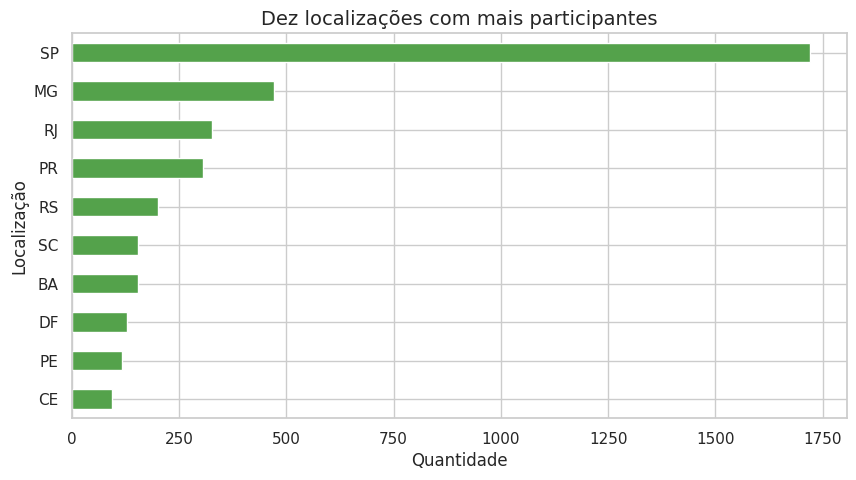

In [46]:
coluna_uf = next((c for c in ["UF ONDE MORA", "Estado", "ESTADO ONDE MORA"] if c in dados.columns), None)

if coluna_uf:
    localizacao = dados[coluna_uf].dropna().value_counts().head(10).sort_values()
    localizacao.plot(kind="barh", color="#54A24B", title="Dez localizações com mais participantes")
    plt.xlabel("Quantidade")
    plt.ylabel("Localização")
    plt.show()
else:
    print("Não há coluna de localização disponível.")

## 8. Comparações salariais

As comparações a seguir são descritivas. Diferenças entre grupos podem estar associadas a experiência, cargo, senioridade, setor, localização e outros fatores não controlados nesta análise.

In [47]:
salario_genero = (
    dados.dropna(subset=["SALARIO"])
    .groupby("GENERO")["SALARIO"]
    .agg(quantidade="size", média="mean", mediana="median")
    .sort_values("mediana", ascending=False)
)
salario_genero.assign(
    média=salario_genero["média"].map(moeda),
    mediana=salario_genero["mediana"].map(moeda),
)

,quantidade,média,mediana
GENERO,,,
Feminino,1047,"R$ 8.484,62","R$ 7.625,50"
Masculino,3131,"R$ 10.411,00","R$ 7.625,50"
Prefiro não informar,19,"R$ 7.592,08","R$ 7.625,50"


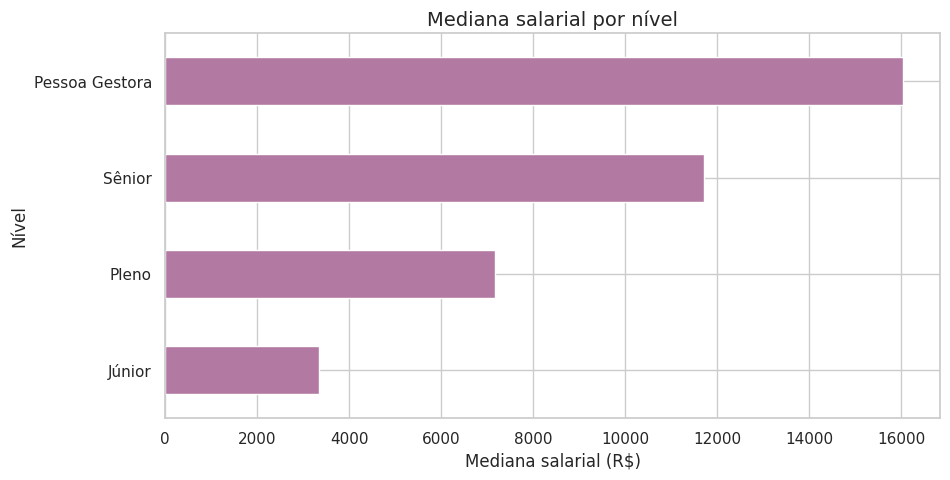

,quantidade,mediana
NIVEL_ANALISE,,
Júnior,1010,"R$ 3.350,00"
Pleno,1050,"R$ 7.168,50"
Sênior,883,"R$ 11.714,00"
Pessoa Gestora,700,"R$ 16.044,00"


In [48]:
nivel_valido = dados.dropna(subset=["NIVEL_ANALISE", "SALARIO"])

if not nivel_valido.empty:
    salario_nivel = (
        nivel_valido.groupby("NIVEL_ANALISE")["SALARIO"]
        .agg(quantidade="size", mediana="median")
        .query("quantidade >= 5")
        .sort_values("mediana")
    )
    salario_nivel["mediana"].plot(kind="barh", color="#B279A2", title="Mediana salarial por nível")
    plt.xlabel("Mediana salarial (R$)")
    plt.ylabel("Nível")
    plt.show()
    display(salario_nivel.assign(mediana=salario_nivel["mediana"].map(moeda)))
else:
    salario_nivel = pd.DataFrame()
    print("Não há dados suficientes para analisar salário por nível.")

In [49]:
coluna_experiencia = next(
    (c for c in dados.columns if "EXPERIÊNCIA NA ÁREA DE DADOS" in c.upper()),
    None,
)

if coluna_experiencia:
    salario_experiencia = (
        dados.dropna(subset=[coluna_experiencia, "SALARIO"])
        .groupby(coluna_experiencia)["SALARIO"]
        .agg(quantidade="size", mediana="median")
        .sort_values("mediana")
    )
    display(salario_experiencia.assign(mediana=salario_experiencia["mediana"].map(moeda)))
else:
    salario_experiencia = pd.DataFrame()
    print("A coluna de experiência não está disponível.")

,quantidade,mediana
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,,
Menos de 1 ano,587,"R$ 3.313,00"
Não tenho experiência na área de dados,185,"R$ 3.397,00"
de 1 a 2 anos,970,"R$ 5.695,00"
de 3 a 4 anos,710,"R$ 10.610,50"
de 4 a 6 anos,520,"R$ 11.796,00"
de 7 a 10 anos,292,"R$ 13.175,50"
Mais de 10 anos,379,"R$ 15.947,00"


## 9. Análises estatísticas

São calculados o intervalo de confiança da média salarial, a correlação de Pearson entre idade e salário e o V de Cramér para duas variáveis categóricas.

In [50]:
n = salarios.count()
media_salario = salarios.mean()
erro_padrao = stats.sem(salarios, nan_policy="omit")
ic95 = stats.t.interval(0.95, df=n - 1, loc=media_salario, scale=erro_padrao)

print(f"Média amostral: {moeda(media_salario)}")
print(f"Intervalo de confiança de 95%: {moeda(ic95[0])} a {moeda(ic95[1])}")

Média amostral: R$ 9.917,68
Intervalo de confiança de 95%: R$ 9.665,78 a R$ 10.169,57


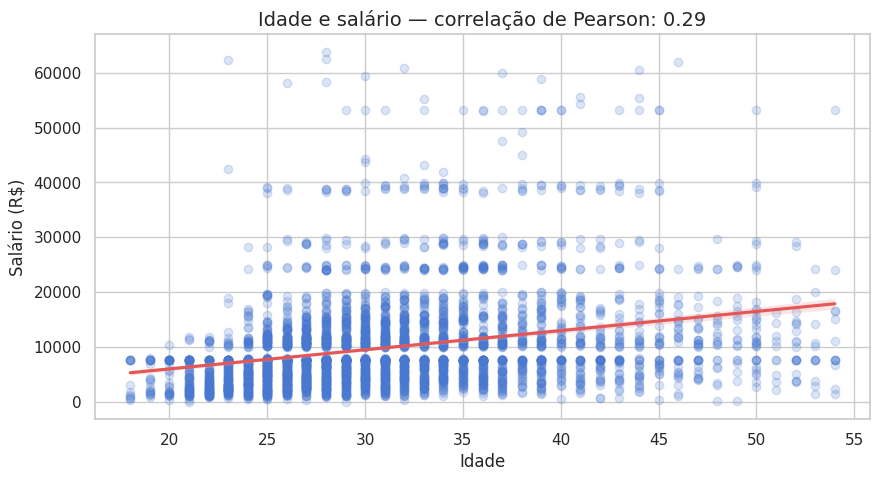

In [51]:
idade_salario = dados[["IDADE_VALIDA", "SALARIO"]].dropna()
correlacao = idade_salario["IDADE_VALIDA"].corr(idade_salario["SALARIO"])

fig, ax = plt.subplots()
sns.regplot(
    data=idade_salario,
    x="IDADE_VALIDA",
    y="SALARIO",
    scatter_kws={"alpha": 0.20},
    line_kws={"color": "#E45756"},
    ax=ax,
)
ax.set(title=f"Idade e salário — correlação de Pearson: {correlacao:.2f}", xlabel="Idade", ylabel="Salário (R$)")
plt.show()

In [52]:
def cramer_v(coluna_a, coluna_b):
    tabela = pd.crosstab(coluna_a, coluna_b)
    if tabela.empty:
        return np.nan
    chi2 = chi2_contingency(tabela)[0]
    n = tabela.to_numpy().sum()
    linhas, colunas = tabela.shape
    denominador = min(linhas - 1, colunas - 1)
    return np.sqrt((chi2 / n) / denominador) if denominador > 0 else np.nan


if "NIVEL DE ENSINO" in dados.columns:
    associacao_genero_ensino = cramer_v(dados["GENERO"], dados["NIVEL DE ENSINO"])
    print(f"V de Cramér entre gênero e nível de ensino: {associacao_genero_ensino:.3f}")
else:
    associacao_genero_ensino = np.nan
    print("Não foi possível calcular o V de Cramér: coluna ausente.")

V de Cramér entre gênero e nível de ensino: 0.066


## 10. Demonstração de SQL

Para demonstrar a integração entre Pandas e banco de dados, os dados preparados são carregados em uma base SQLite em memória. A consulta agrega quantidade, média, mínimo e máximo salarial por gênero.

In [53]:
conexao = sqlite3.connect(":memory:")
dados[["GENERO", "SALARIO"]].to_sql("profissionais", conexao, index=False, if_exists="replace")

consulta = '''
SELECT
    GENERO AS genero,
    COUNT(SALARIO) AS quantidade,
    ROUND(AVG(SALARIO), 2) AS media_salarial,
    MIN(SALARIO) AS menor_salario,
    MAX(SALARIO) AS maior_salario
FROM profissionais
WHERE SALARIO IS NOT NULL
GROUP BY GENERO
ORDER BY media_salarial DESC;
'''

resultado_sql = pd.read_sql_query(consulta, conexao)
conexao.close()
resultado_sql

,genero,quantidade,media_salarial,menor_salario,maior_salario
0,Masculino,3131,10411.00,51.0,63813.0
1,Feminino,1047,8484.62,35.0,62577.0
2,Prefiro não informar,19,7592.08,1339.0,18282.0


## 11. Principais resultados

A célula seguinte gera uma síntese baseada nos dados efetivamente carregados. Assim, os números apresentados permanecem consistentes mesmo quando a base é atualizada.

In [54]:
genero_mais_frequente = dados["GENERO"].mode().iat[0]
idade_mediana = dados["IDADE_VALIDA"].median()

resultados = f'''
### Síntese automática

- **Registros analisados:** {len(dados):,}
- **Salários válidos:** {len(salarios):,}
- **Mediana salarial:** {moeda(salarios.median())}
- **Média salarial:** {moeda(salarios.mean())}
- **Intervalo de confiança de 95% para a média:** {moeda(ic95[0])} a {moeda(ic95[1])}
- **Idade mediana:** {idade_mediana:.0f} anos
- **Categoria de gênero mais frequente:** {genero_mais_frequente}
- **Correlação entre idade e salário:** {correlacao:.2f}
- **Possíveis outliers salariais pelo IQR:** {len(possiveis_outliers):,}
'''
display(Markdown(resultados))


### Síntese automática

- **Registros analisados:** 4,197
- **Salários válidos:** 4,197
- **Mediana salarial:** R$ 7.625,50
- **Média salarial:** R$ 9.917,68
- **Intervalo de confiança de 95% para a média:** R$ 9.665,78 a R$ 10.169,57
- **Idade mediana:** 30 anos
- **Categoria de gênero mais frequente:** Masculino
- **Correlação entre idade e salário:** 0.29
- **Possíveis outliers salariais pelo IQR:** 322


In [55]:
forca_correlacao = (
    "muito fraca" if abs(correlacao) < 0.20 else
    "fraca" if abs(correlacao) < 0.40 else
    "moderada" if abs(correlacao) < 0.70 else
    "forte"
)
direcao = "positiva" if correlacao > 0 else "negativa" if correlacao < 0 else "nula"

conclusao = f'''
## 12. Conclusão

A análise descreveu **{len(dados):,} respostas** e mostrou uma distribuição salarial assimétrica, com mediana de **{moeda(salarios.median())}**. Por esse motivo, a mediana é uma referência central mais resistente aos valores extremos do que a média.

A relação entre idade e salário foi **{direcao} e {forca_correlacao}** (r = **{correlacao:.2f}**). Esse resultado indica associação, mas não permite afirmar que a idade cause mudanças salariais. Cargo, senioridade, experiência, setor e localização também podem contribuir para as diferenças observadas.

Os possíveis outliers foram mantidos. Essa escolha evita apagar salários reais apenas porque são pouco frequentes. Para decisões futuras, recomenda-se ampliar a análise com modelos multivariados e avaliar conjuntamente experiência, nível profissional e localização.
'''
display(Markdown(conclusao))


## 12. Conclusão

A análise descreveu **4,197 respostas** e mostrou uma distribuição salarial assimétrica, com mediana de **R$ 7.625,50**. Por esse motivo, a mediana é uma referência central mais resistente aos valores extremos do que a média.

A relação entre idade e salário foi **positiva e fraca** (r = **0.29**). Esse resultado indica associação, mas não permite afirmar que a idade cause mudanças salariais. Cargo, senioridade, experiência, setor e localização também podem contribuir para as diferenças observadas.

Os possíveis outliers foram mantidos. Essa escolha evita apagar salários reais apenas porque são pouco frequentes. Para decisões futuras, recomenda-se ampliar a análise com modelos multivariados e avaliar conjuntamente experiência, nível profissional e localização.


## 13. Limitações

- A base representa participantes de uma pesquisa e pode não refletir toda a população de profissionais de dados.
- Algumas categorias possuem poucas observações.
- Valores ausentes reduzem a quantidade de registros em análises específicas.
- As comparações não controlam simultaneamente experiência, cargo, setor e localização.
- Correlação e associação não significam causalidade.

## 14. Próximos passos

- Criar um dashboard no Power BI com os principais indicadores;
- Investigar salários por senioridade, experiência e região;
- Aplicar modelos estatísticos multivariados;


---

**Kamilly Higino**  
Graduanda em Ciência da Computação | Interesse em Análise de Dados